In [1]:
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.signal import spectrogram
from scipy.ndimage import gaussian_filter1d
from scipy.signal import convolve
from scipy.signal import find_peaks
import random

In [2]:
class Pipeline:

    d = None
    
    x_diff = None
    y_diff = None

    x_mask = None
    y_mask = None
    mask= None

    saccade_signals = None
    saccade_gen = None
    saccade_seq = None
    
    
    def __init__(self, t, x, y, x_left, y_left):
        self.t = t
        self.x = x
        self.y = y
        self.x_left = x_left
        self.y_left = y_left

    def run(self):
        
        (
        self.t,
        self.x,
        self.y,
        self.x_left,
        self.y_left
        ) = self.__drop_nans_with_context(self.t, self.x, self.y, self.x_left, self.y_left, context_size=5)
        
        self.t = self.__normalization_min_max_positive(self.t)
        self.x = self.__normalization_min_max(self.x)
        self.y = self.__normalization_min_max(self.y)
        self.x_left = self.__normalization_min_max(self.x_left)
        self.y_left = self.__normalization_min_max(self.y_left)

        self.d = self.__calculate_distance(self.x, self.y)
        
        self.__calculate_diff()
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)
        
        self.x_diff = self.__highpass_filtering(self.x_diff)
        self.y_diff = self.__highpass_filtering(self.y_diff)
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__smooth_signal(self.x_diff)
        self.y_diff = self.__smooth_signal(self.y_diff)

        self.x_diff = self.__highligth_peaks(self.x_diff)
        self.y_diff = self.__highligth_peaks(self.y_diff)

        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__lowpass_filtering(self.x_diff)
        self.y_diff = self.__lowpass_filtering(self.y_diff)
        
        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__zero_outliers(self.x_diff)
        self.y_diff = self.__zero_outliers(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_mask = self.__detect_peaks(self.x_diff, prominence=0.05, distance=10)
        self.y_mask = self.__detect_peaks(self.y_diff, prominence=0.05, distance=10)

        # self.__plot_results()

        self.mask = self.x_mask + self.y_mask
        self.saccade_signals = self.__extract_peak_segments(self.d, self.mask, context_size=10)

        self.saccade_gen = self.__generate_smoothed_signal(self.saccade_signals)

        self.saccade_seq = next(self.saccade_gen)

        self.saccade_seq = self.__highpass_filtering(self.saccade_seq)

        self.saccade_seq = self.__normalization_min_max(self.saccade_seq)
        
        return self.saccade_seq

    def __drop_nans_with_context(self, *signals, context_size=5):
        assert len(signals) > 0, "At least one signal must be provided."
    
        signals = [pd.Series(sig).reset_index(drop=True) if not isinstance(sig, pd.Series) else sig.reset_index(drop=True) for sig in signals]
        nan_indices = np.unique(np.concatenate([
            sig[sig.isna() | (sig == "nan")].index for sig in signals
        ]))
    
        if len(nan_indices) == 0:
            return signals

        expanded_indices = np.unique(np.concatenate([
            np.arange(max(0, idx - context_size), min(len(signals[0]), idx + context_size + 1))
            for idx in nan_indices
        ]))
    
        filtered_signals = [sig.drop(expanded_indices).reset_index(drop=True) for sig in signals]
    
        filtered_signals = [sig.dropna().reset_index(drop=True) for sig in filtered_signals]
    
        min_length = min(map(len, filtered_signals))
        filtered_signals = [sig.iloc[:min_length].reset_index(drop=True) for sig in filtered_signals]
    
        return tuple(filtered_signals)

    def __calculate_distance(self, x, y):
        return np.sqrt(np.power(x, 2) + np.power(y, 2))
        
    def __calculate_diff(self):
        self.x_diff = abs(self.x - self.x_left)
        self.y_diff = abs(self.y - self.y_left)

    def __normalization_min_max_positive(self, signal):
        return (signal - signal.min()) / (signal.max() - signal.min())

    def __normalization_min_max(self, signal):
        return 2*((signal - signal.min()) / (signal.max() - signal.min())) - 1

    def __strech_signal(self, signal):
        power = 2
        mean = signal.mean()
        
        signal = np.power(signal, power)
        signal = signal / signal.mean() * mean

        return signal

    def __highpass_filtering(self, signal):
        def highpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='high', analog=False)  # Change to 'high'
            return filtfilt(b, a, data)

        return highpass_filter(signal)

    def __smooth_signal(self, signal, sigma=5):
        return gaussian_filter1d(signal, sigma=sigma)

    def __highligth_peaks(self,signal):
        difference_kernel = np.array([-1,-1, 0, 1,1]) 
        return convolve(signal, difference_kernel, mode="same")

    def __lowpass_filtering(self, signal):
        def lowpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='low', analog=False)
            return filtfilt(b, a, data)

        return lowpass_filter(signal)

    def __zero_outliers(self, signal):
        Q1 = np.percentile(signal, 5) 
        Q3 = np.percentile(signal, 95)
        IQR = Q3 - Q1
        
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        filtered_signal = signal.copy()
        filtered_signal[(filtered_signal < lower) | (filtered_signal > upper)] = 0
    
        return filtered_signal

    def __detect_peaks(self, signal, height=None, prominence=0.1, distance=5):
        signal = np.array(signal)
        peaks, _ = find_peaks(signal, height=height, prominence=prominence, distance=distance)
        peak_mask = np.zeros(len(signal), dtype=int)
        peak_mask[peaks] = 1
        
        return peak_mask

    def __plot_results(self):

        start = 32498
        end = start + 200
        
        fig, axes = plt.subplots(6, 1, figsize=(8, 8), sharex=True)
        
        axes[0].plot(self.t.iloc[start:end], self.x.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[0].set_ylabel("X Position Rigth Eye")
        axes[0].set_title("X vs Time")
        axes[0].grid(True)
        
        axes[1].plot(self.t.iloc[start:end], self.x_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[1].set_xlabel("Time (Normalized)")
        axes[1].set_ylabel("X Position Left Eye")
        axes[1].set_title("X vs Time")
        axes[1].grid(True)
        
        axes[2].plot(self.t.iloc[start:end], self.x_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[2].set_xlabel("Time (Normalized)")
        axes[2].set_ylabel("X Diffrence")
        axes[2].set_title("saccade movement")
        axes[2].grid(True)

        axes[3].plot(self.t.iloc[start:end], self.y.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[3].set_ylabel("X Position Rigth Eye")
        axes[3].set_title("Y vs Time")
        axes[3].grid(True)
        
        axes[4].plot(self.t.iloc[start:end], self.y_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[4].set_xlabel("Time (Normalized)")
        axes[4].set_ylabel("X Position Left Eye")
        axes[4].set_title("Y vs Time")
        axes[4].grid(True)
        
        axes[5].plot(self.t.iloc[start:end], self.y_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[5].set_xlabel("Time (Normalized)")
        axes[5].set_ylabel("X Diffrence")
        axes[5].set_title("saccade movement")
        axes[5].grid(True)
        
        plt.tight_layout()
        plt.show()

    def __extract_peak_segments(self, signal, mask, context_size=5):
        signal = np.array(signal)
        mask = np.array(mask)
    
        assert len(signal) == len(mask), "Signal and mask must have the same length."
    
        extracted_segments = []
        peak_indices = np.where(mask == 1)[0]
    
        for idx in peak_indices:
            start = max(0, idx - context_size)
            end = min(len(signal), idx + context_size + 1)
            
            extracted_segments.append(signal[start:end])
        return extracted_segments

    def __generate_smoothed_signal(self, fragments):
        if not fragments:
            return
        random.shuffle(fragments)
        smoothed_signal = [fragments[0]]
    
        last_value = fragments[0][-1]
    
        for i in range(1, len(fragments)):
            shift = last_value - fragments[i][0]
            translated_fragment = fragments[i] + shift
    
            smoothed_signal.append(translated_fragment)
            last_value = translated_fragment[-1]

        yield np.concatenate(smoothed_signal)

31080


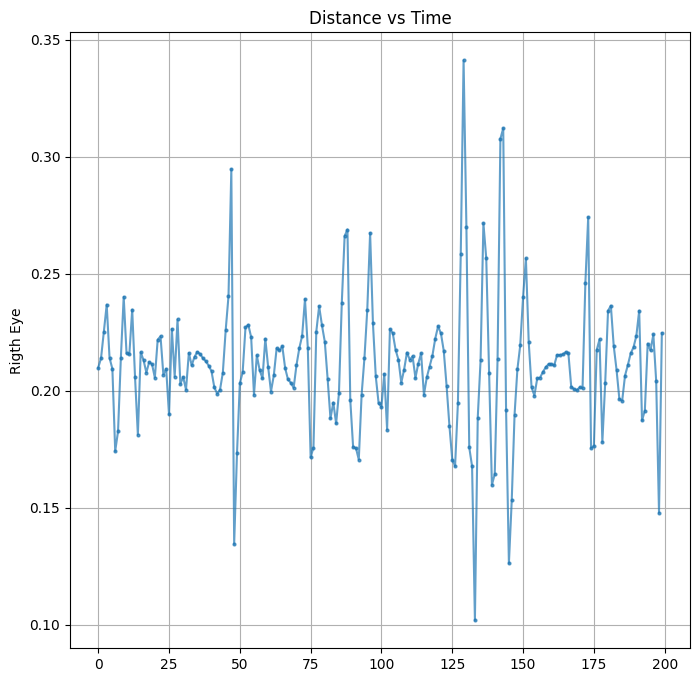

In [3]:
file_path = "../data/00/data.csv"
df = pd.read_csv(file_path)

selected_columns = ["t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
                    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"]
df = df[selected_columns]

df = df.rename(columns={
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
})

pipeline = Pipeline(df["t"], df["x"], df["y"], df["x_left"], df["y_left"])
saccade_seq = pipeline.run()

start = 2000
end = start + 200

fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharex=True)

axes.plot(saccade_seq[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
axes.set_ylabel("Rigth Eye")
axes.set_title("Distance vs Time")
axes.grid(True)

print(len(saccade_seq))

In [4]:
labels_num = 2

In [5]:
import pandas as pd

# Selected columns to read from each CSV file
selected_columns = [
    "t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"
]

# Renaming dictionary (base names)
rename_dict = {
    "t": "t", 
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
}

# List to store all DataFrames
df_list = []

# Load each CSV file and process it
for i in range(labels_num):  # Loop from 00 to 09
    file_path = f"../data/{i:02d}/data.csv"  # Format path dynamically
    
    # Load CSV, only select needed columns
    df = pd.read_csv(file_path, usecols=selected_columns)
    
    # Trim to 100,000 rows
    df = df.iloc[:100000]
    
    # Rename columns with appropriate suffix
    df = df.rename(columns={col: f"{rename_dict[col]}{i:02d}" for col in selected_columns})
    
    # Append processed DataFrame to the list
    df_list.append(df)

# Concatenate all DataFrames side-by-side
merged_df = pd.concat(df_list, axis=1)

merged_df.head()


,t00,x00,y00,x_left00,y_left00,t01,x01,y01,x_left01,y_left01
0,1.581362e+15,-29.585846,1.740021,32.436142,5.695251,1.583335e+15,-33.649307,0.915329,29.914169,4.788696
1,1.581362e+15,-29.591797,1.740555,32.421951,5.614624,1.583335e+15,-33.651520,0.925964,29.914185,4.745239
2,1.581362e+15,-29.599228,1.711990,32.406448,5.580765,1.583335e+15,-33.654449,0.910370,29.913483,4.757553
3,1.581362e+15,-29.606445,1.710693,32.386810,5.647583,1.583335e+15,-33.655487,0.906570,29.913757,4.726425
4,1.581362e+15,-29.615341,1.769791,32.370270,5.730347,1.583335e+15,-33.656067,0.902786,29.921448,4.677521


In [6]:
import pandas as pd
import numpy as np

# List of signal types to extract
signal_types = ["t", "x", "y", "x_left", "y_left"]

# Create an empty list to store instances
instances = []

# Iterate over the 10 labels (00 to 09)
for i in range(labels_num):  
    label = i  # Assign label from 0 to 9
    
    for signal_type in signal_types:  # Iterate over all signal types
        signal = merged_df[f"{signal_type}{i:02d}"]  # Extract the correct column
        
        # Split the signal into 10 segments of 10,000 each
        for j in range(10):
            segment = signal[j * 10000 : (j + 1) * 10000].values  # Extract 10,000-length segment
            
            # Create a row with label, signal type, segment number, and signal values
            instance = [label, signal_type, j + 1] + list(segment)  # j+1 to start segments from 1
            
            # Store instance
            instances.append(instance)

# Define column names
columns = ["label", "signal_type", "segment"] + [f"dim_{i}" for i in range(10000)]

# Convert list to DataFrame
df_processed = pd.DataFrame(instances, columns=columns)

df_processed.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [7]:
df_train_raw = df_processed[df_processed["segment"].between(1, 7)]
df_test_raw = df_processed[df_processed["segment"].between(8, 10)]

In [8]:
df_train_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [9]:
df_test_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
7,0,t,8,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
8,0,t,9,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
9,0,t,10,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
17,0,x,8,-2.988655e+01,-2.988634e+01,-2.988655e+01,-2.988661e+01,-2.988666e+01,-2.988678e+01,-2.988690e+01,...,-2.988496e+01,-2.988054e+01,-2.987500e+01,-2.988220e+01,-2.986838e+01,-2.987280e+01,-2.985788e+01,-2.986806e+01,-2.986948e+01,-2.987563e+01
18,0,x,9,-2.990927e+01,-2.998026e+01,-3.002446e+01,-3.001945e+01,-3.001668e+01,-3.001811e+01,-3.003775e+01,...,-3.049767e+01,-3.049767e+01,-3.049767e+01,-3.049771e+01,-3.049779e+01,-3.049789e+01,-3.048491e+01,-3.037790e+01,-3.016847e+01,-2.997070e+01


# features generation

(10000,)
-30.45625305175781
Generated signal: [0.1232416  0.12050427 0.12083805 ... 0.12185248 0.12311089 0.12211231]


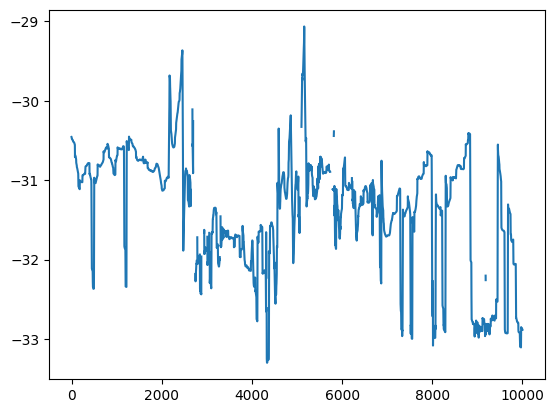

In [10]:
# Select a specific label and segment
label = df_train_raw["label"].unique()[1]  # Select the first label
segment = df_train_raw[df_train_raw["label"] == label]["segment"].unique()[2]  # Select the first segment for that label

# Filter the dataframe for the selected label and segment
df_segment = df_train_raw[(df_train_raw["label"] == label) & (df_train_raw["segment"] == segment)]

# Extract input signals based on signal_type
t = df_segment[df_segment["signal_type"] == "t"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
x = df_segment[df_segment["signal_type"] == "x"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
y = df_segment[df_segment["signal_type"] == "y"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
x_left = df_segment[df_segment["signal_type"] == "x_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
y_left = df_segment[df_segment["signal_type"] == "y_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()

plt.plot(x)
print(x.shape)
print(x[0])
# Run the pipeline
pipeline = Pipeline(t, x, y, x_left, y_left)
saccade_seq = pipeline.run()

# Print the result
print("Generated signal:", saccade_seq)


In [11]:
def generate_features(df):
    generated_signals = []
    generated_labels = []
    
    # Iterate over unique labels
    for label in df["label"].unique():
        df_label = df[df["label"] == label]
    
        # Iterate over unique segments
        for segment in df_label["segment"].unique():
            df_segment = df_label[df_label["segment"] == segment]
    
            # Extract input signals for the pipeline based on signal_type
            t = df_segment[df_segment["signal_type"] == "t"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x = df_segment[df_segment["signal_type"] == "x"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y = df_segment[df_segment["signal_type"] == "y"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x_left = df_segment[df_segment["signal_type"] == "x_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y_left = df_segment[df_segment["signal_type"] == "y_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
    
            # Run the pipeline 10 times for each segment
            for _ in range(100):
                pipeline = Pipeline(t, x, y, x_left, y_left)
                saccade_seq = pipeline.run()
                
                # Store the generated signal and label
                generated_signals.append(saccade_seq)
                generated_labels.append(label)
    
    # Convert results into DataFrame
    return pd.DataFrame(generated_signals), pd.DataFrame({"label": generated_labels})

df_train, df_train_labels = generate_features(df_train_raw)
df_train = df_train.iloc[:, :1000]

df_test, df_test_labels = generate_features(df_test_raw)
df_test = df_test.iloc[:, :1000]

In [12]:
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.164559,0.171729,0.164334,0.163146,0.173664,0.137672,0.116854,0.161881,0.230384,0.171881,...,0.204025,0.243438,0.246697,0.195149,0.092585,-0.075132,-0.288639,0.620664,0.420538,0.220617
1,0.164552,0.166626,0.159985,0.165513,0.160162,0.161750,0.184899,0.142874,0.176888,0.153375,...,0.339486,0.021509,0.152657,0.088577,0.201462,0.160230,0.032169,0.198416,0.330783,0.206432
2,0.163788,0.141760,0.186990,0.171644,0.160309,0.162848,0.162495,0.168335,0.177933,0.179595,...,0.171175,0.170246,0.166938,0.219907,0.107672,0.130056,0.149414,0.185386,0.182720,0.180579
3,0.165290,0.168848,0.173894,0.177198,0.152682,0.164139,0.163985,0.163214,0.165025,0.161114,...,0.165025,0.161171,0.160521,0.165260,0.171737,0.165372,0.160678,0.162050,0.166801,0.168586
4,0.165584,0.168389,0.181880,0.212756,0.259489,0.224818,0.133019,-0.036556,0.032183,0.196486,...,0.019978,0.339698,0.280895,0.229720,0.183205,0.130565,-0.032833,0.028769,0.219431,0.289536


In [13]:
df_train_labels.head()

,label
0,0
1,0
2,0
3,0
4,0


In [14]:
df_test.head()

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,-0.244225,-0.249974,-0.254827,-0.257200,-0.255296,-0.247660,-0.234914,-0.217903,-0.182949,-0.191862,...,-0.255331,-0.257856,-0.243468,-0.249286,-0.246300,-0.237046,-0.222013,-0.198099,-0.293660,-0.252899
1,-0.248488,-0.247474,-0.243831,-0.239197,-0.246733,-0.245526,-0.241351,-0.243646,-0.250471,-0.256612,...,-0.272998,-0.323962,-0.282616,-0.208096,-0.082884,-0.144577,-0.195279,-0.450356,-0.391346,-0.249927
2,-0.243110,-0.222415,-0.201738,-0.203640,-0.206094,-0.261317,-0.349912,-0.444322,-0.512919,0.285453,...,-0.254486,-0.247962,-0.235675,-0.218623,-0.183281,-0.191870,-0.326970,-0.377327,-0.243897,-0.193333
3,-0.240406,-0.243246,-0.236829,-0.230819,-0.226811,-0.227269,-0.234686,-0.250267,-0.271249,-0.286501,...,-0.247872,-0.246888,-0.267112,-0.194639,-0.259613,-0.164959,-0.202137,-0.375697,-0.244356,-0.227377
4,-0.242534,-0.554005,-0.641109,-0.269721,-0.109354,-0.139846,-0.326627,-0.600908,0.291786,0.045660,...,-0.238874,-0.245258,-0.249200,-0.245973,-0.244431,-0.241878,-0.240908,-0.229307,-0.231913,-0.230475


In [15]:
df_test_labels.head()

,label
0,0
1,0
2,0
3,0
4,0


In [16]:
shuffled_indices = df_train.sample(frac=1, random_state=42).index

df_train = df_train.loc[shuffled_indices].reset_index(drop=True)
df_train_labels = df_train_labels.loc[shuffled_indices].reset_index(drop=True)

shuffled_indices = df_test.sample(frac=1, random_state=42).index

df_test = df_test.loc[shuffled_indices].reset_index(drop=True)
df_test_labels = df_test_labels.loc[shuffled_indices].reset_index(drop=True)

# Machine Learning

## Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [18]:
y_train = df_train_labels["label"].values
y_test = df_test_labels["label"].values

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(df_train, y_train)

y_pred = clf.predict(df_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)

Test Accuracy: 0.4783
Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.40      0.43       300
           1       0.48      0.56      0.52       300

    accuracy                           0.48       600
   macro avg       0.48      0.48      0.48       600
weighted avg       0.48      0.48      0.48       600



as expected classical machine learning algorithms are failing

## Deep Learning

In [19]:
import torch
import numpy as np
import random

def set_seed(seed=0):
    torch.manual_seed(seed)  # Sets PyTorch seed (CPU)
    torch.cuda.manual_seed(seed)  # Sets PyTorch seed (GPU)
    torch.cuda.manual_seed_all(seed)  # If using multi-GPU
    np.random.seed(seed)  # Sets NumPy seed
    random.seed(seed)  # Sets Python random seed

    torch.backends.cudnn.deterministic = True  # Ensures deterministic behavior
    torch.backends.cudnn.benchmark = False  # Disables cuDNN optimization for reproducibility

set_seed(0)  # Set seed to 0

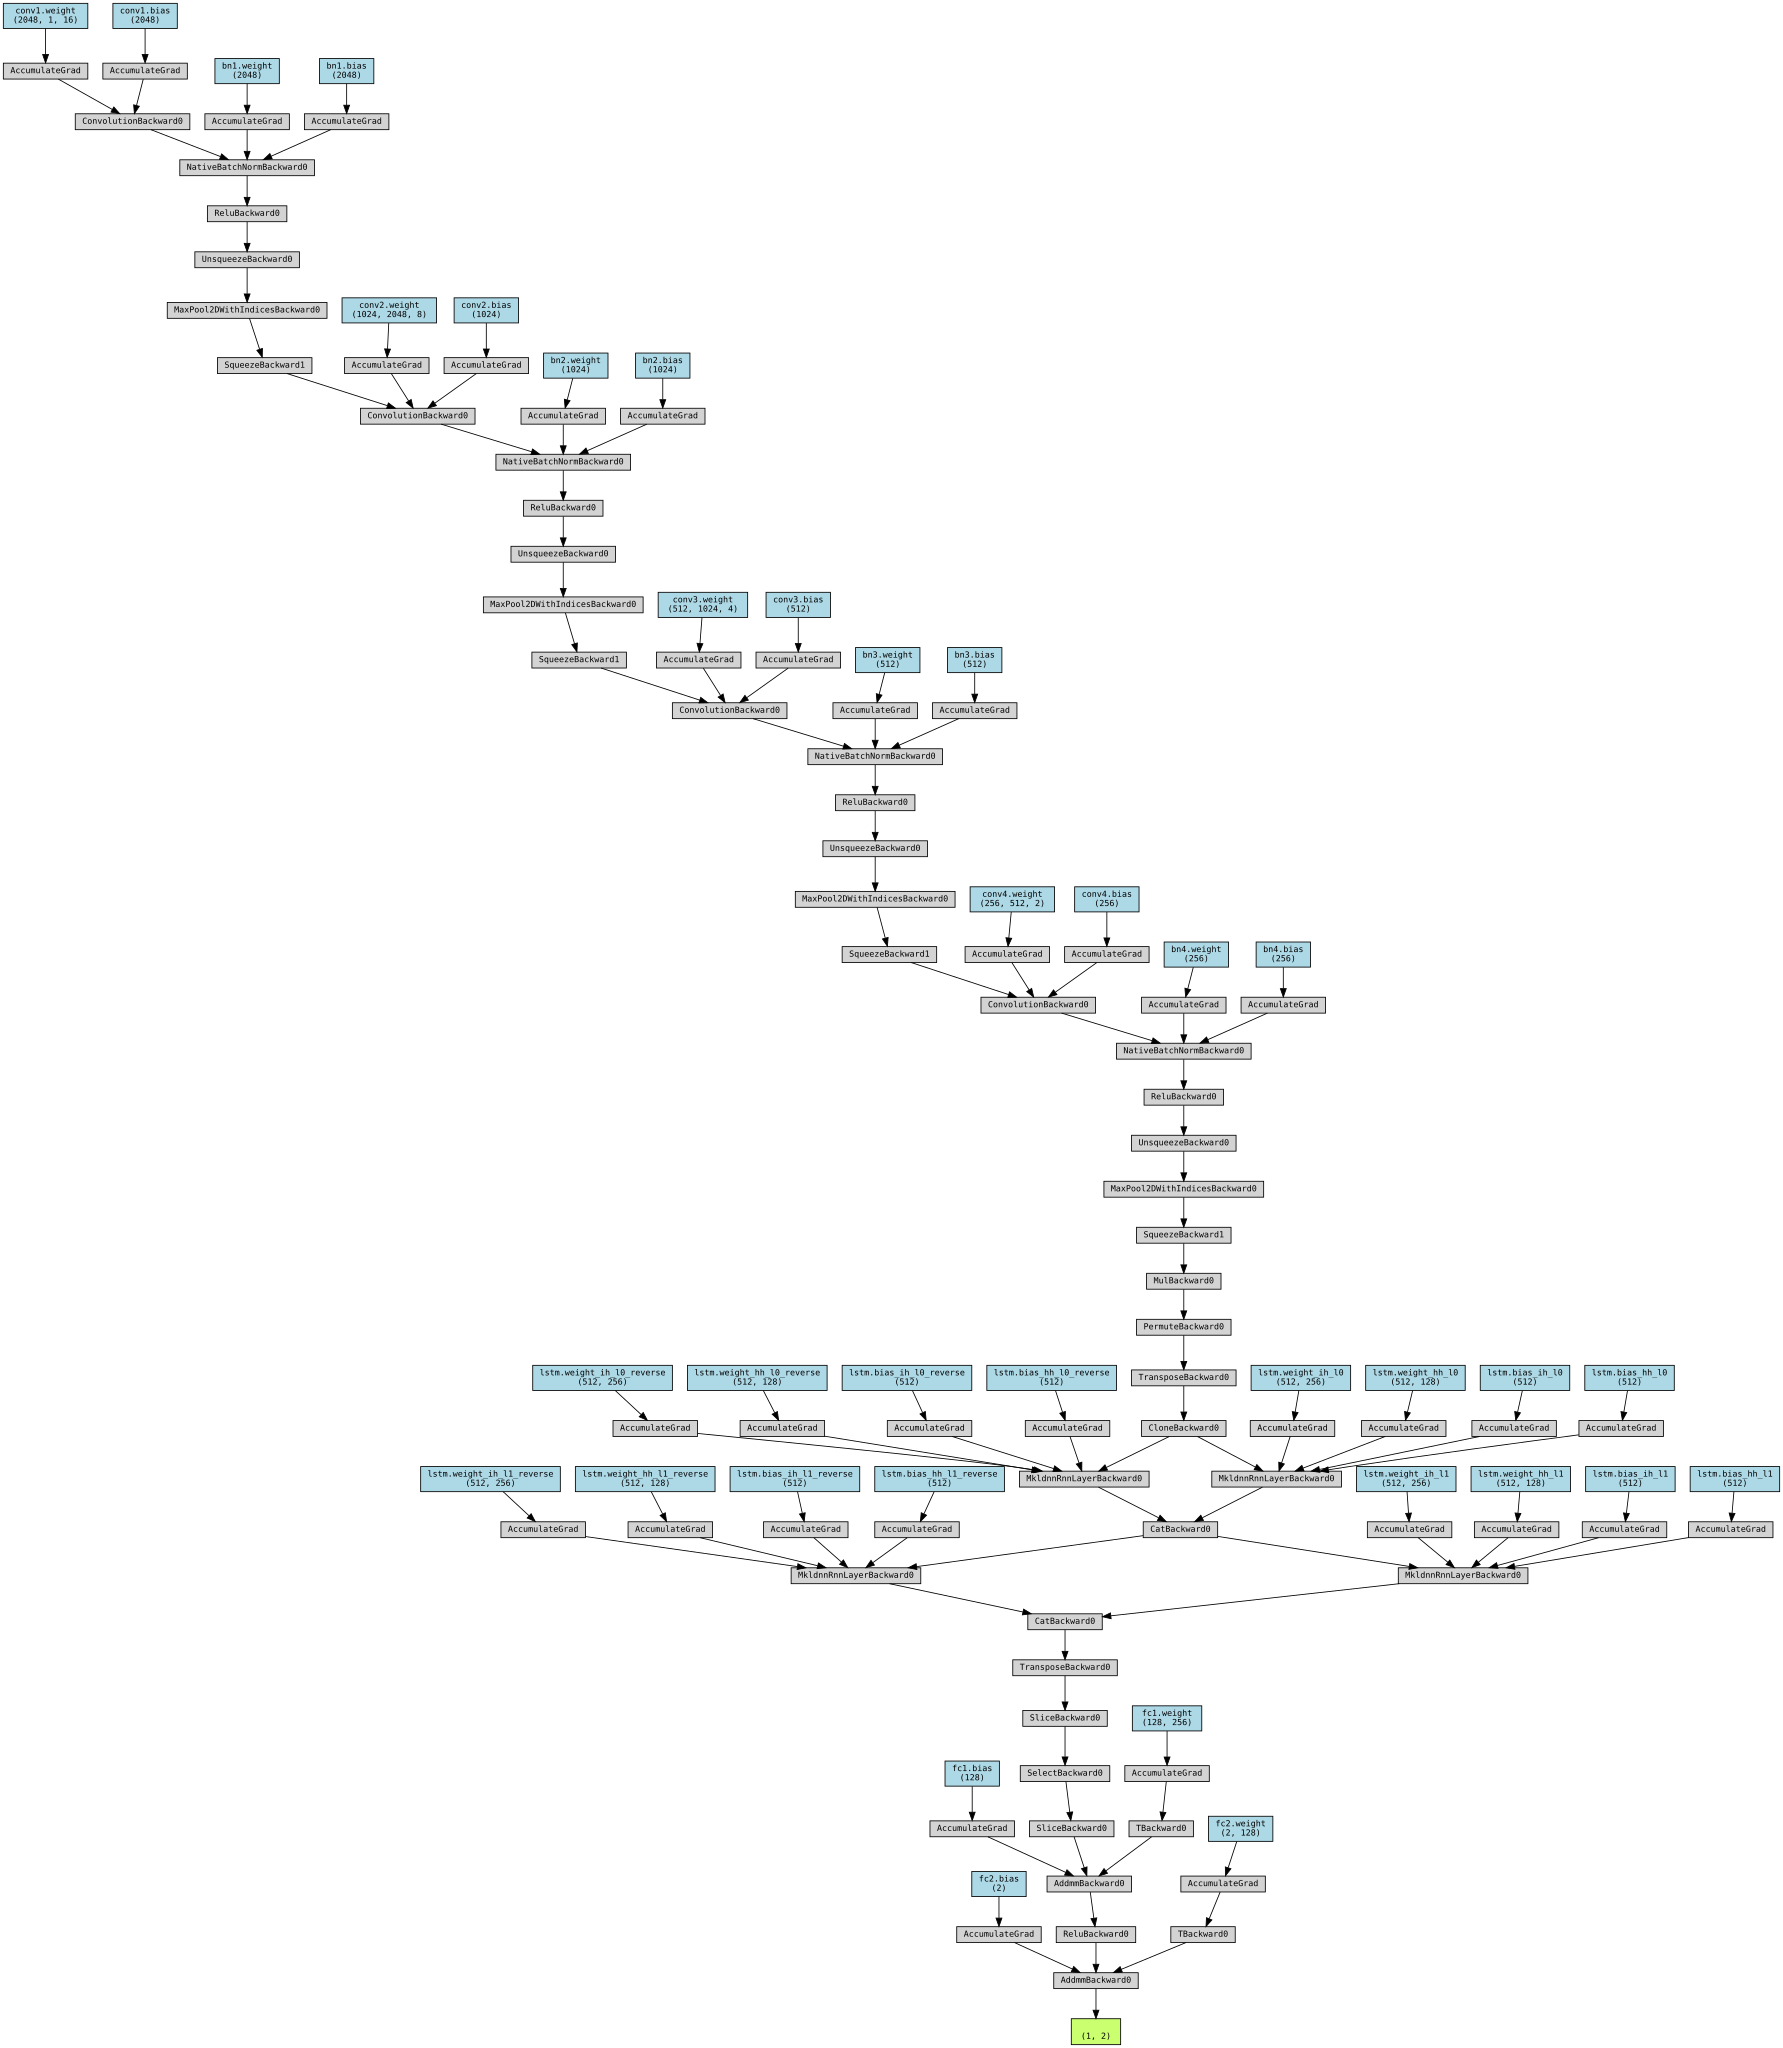

In [29]:
from torchviz import make_dot

# Create a dummy input
dummy_input = torch.randn(1, 1, 1000)  # Batch size 1, 1 channel, sequence length 1000
model = NN(num_classes)

# Forward pass
output = model(dummy_input)

# Create visualization
dot = make_dot(output, params=dict(model.named_parameters()))
dot.render("model_architecture", format="png")  # Save to file
dot  # Display in Jupyter Notebook


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Convert DataFrames to NumPy arrays
X_train = df_train.values.astype(np.float32)
y_train = df_train_labels["label"].values.astype(np.int64)

X_test = df_test.values.astype(np.float32)
y_test = df_test_labels["label"].values.astype(np.int64)

# Define PyTorch Dataset
class SignalDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X).unsqueeze(1)  # Add channel dimension
        self.y = torch.tensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create Dataloaders
train_dataset = SignalDataset(X_train, y_train)
test_dataset = SignalDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# CNN + LSTM
class NN(nn.Module):
    def __init__(self, num_classes):
        super(NN, self).__init__()

        # 1D Convolutional Layers (Feature Extraction)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=2048, kernel_size=16, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(2048)

        self.conv2 = nn.Conv1d(2048, 1024, kernel_size=8, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(1024)

        self.conv3 = nn.Conv1d(1024, 512, kernel_size=4, stride=1, padding=2)
        self.bn3 = nn.BatchNorm1d(512)

        self.conv4 = nn.Conv1d(512, 256, kernel_size=2, stride=1, padding=1)
        self.bn4 = nn.BatchNorm1d(256)

        self.pool = nn.MaxPool1d(kernel_size=4, stride=2)
        self.dropout1 = nn.Dropout(0.3)
        # self.dropout2 = nn.Dropout(0.05)

        # LSTM Layers (Temporal Dependencies)
        self.lstm = nn.LSTM(input_size=256, hidden_size=128, num_layers=2, batch_first=True, bidirectional=True)
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(256, 128)  # 2x128 because of bidirectional LSTM
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # CNN Feature Extraction
        x = self.pool(nn.ReLU()(self.bn1(self.conv1(x))))
        x = self.pool(nn.ReLU()(self.bn2(self.conv2(x))))
        x = self.pool(nn.ReLU()(self.bn3(self.conv3(x))))
        x = self.pool(nn.ReLU()(self.bn4(self.conv4(x))))
        
        x = self.dropout1(x)  # Apply dropout
        
        # Prepare for LSTM (batch_size, seq_length, features)
        x = x.permute(0, 2, 1)  # Swap to (batch_size, seq_len, channels)
        
        # LSTM Processing
        x, _ = self.lstm(x)

        # Take the last time-step's output
        x = x[:, -1, :]

        # Fully Connected Layers
        x = nn.ReLU()(self.fc1(x))
        # x = self.dropout2(x)
        x = self.fc2(x)

        return x

# # CNN
# class NN(nn.Module):
#     def __init__(self, num_classes):
#         super(NN, self).__init__()

#         self.conv1 = nn.Conv1d(in_channels=1, out_channels=1024, kernel_size=11, stride=1, padding=5)
#         self.bn1 = nn.BatchNorm1d(1024)

#         self.conv2 = nn.Conv1d(1024, 512, kernel_size=11, stride=1, padding=4)
#         self.bn2 = nn.BatchNorm1d(512)

#         self.conv3 = nn.Conv1d(512, 256, kernel_size=6, stride=1, padding=3)
#         self.bn3 = nn.BatchNorm1d(256)

#         self.conv4 = nn.Conv1d(256, 256, kernel_size=6, stride=1, padding=2)
#         self.bn4 = nn.BatchNorm1d(256)

#         self.conv5 = nn.Conv1d(256, 256, kernel_size=3, stride=1, padding=1)
#         self.bn5 = nn.BatchNorm1d(256)

#         self.conv6 = nn.Conv1d(256, 256, kernel_size=3, stride=1, padding=1)
#         self.bn6 = nn.BatchNorm1d(256)

#         # Pooling and Dropout Layers
#         self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
#         self.dropout1 = nn.Dropout(0.3)
#         self.dropout2 = nn.Dropout(0.4)

#         # Adaptive Pooling to keep FC layer input size fixed
#         self.global_pool = nn.AdaptiveAvgPool1d(1)

#         # Fully Connected Layers
#         self.fc1 = nn.Linear(256, 128)
#         self.fc2 = nn.Linear(128, num_classes)

#     def forward(self, x):
#         x = self.pool(nn.ReLU()(self.bn1(self.conv1(x))))
#         x = self.pool(nn.ReLU()(self.bn2(self.conv2(x))))
#         x = self.pool(nn.ReLU()(self.bn3(self.conv3(x))))
#         x = self.pool(nn.ReLU()(self.bn4(self.conv4(x))))
#         x = self.pool(nn.ReLU()(self.bn5(self.conv5(x))))
#         x = self.pool(nn.ReLU()(self.bn6(self.conv6(x))))

#         x = self.global_pool(x)  # Output: (batch_size, 1024, 1)
#         x = x.view(x.size(0), -1)  # Flatten: (batch_size, 1024)

#         x = self.dropout1(nn.ReLU()(self.fc1(x)))
#         x = self.dropout2(self.fc2(x))

#         return x
        
# Initialize Model
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training Loop
def train_model(model, train_loader, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Train Model
train_model(model, train_loader, num_epochs=10)

# Function to evaluate model and display confusion matrix
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nClassification Report:\n", classification_report(all_labels, all_preds))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Test the model and show confusion matrix
evaluate_model(model, test_loader)



Epoch 1/10, Loss: 27.1156, Accuracy: 74.79%
Epoch 2/10, Loss: 19.7414, Accuracy: 82.00%
Epoch 3/10, Loss: 15.2052, Accuracy: 85.50%
Epoch 4/10, Loss: 12.1951, Accuracy: 88.36%
Epoch 5/10, Loss: 9.8687, Accuracy: 92.00%
Epoch 6/10, Loss: 8.8444, Accuracy: 92.50%
Epoch 7/10, Loss: 5.6578, Accuracy: 96.07%
